# Customer Lifestyle Segmentation Using Credit Card Transactions

## Why This Project

This started as a frustrating moment as a cardholder, not an academic exercise. During a family trip to London, my card worked fine for the first few Tube taps, then started getting declined on the exact same small transit charges — despite plenty of available credit and years of clean history with the issuer. From the bank's side, a foreign city, repeated small transactions, and a sudden change in spending pattern probably looked like fraud. From my side, it was just a normal summer trip.

That gap — between how a risk model sees a customer and how the customer actually lives — is what this project investigates. Rule-based heuristics (country changes, amount thresholds, merchant blacklists) are easy to implement, but they flatten very different lifestyles into the same bucket: a frequent traveler and a family concentrated on groceries and fuel can trip the same rule for very different reasons. The goal here is to let transaction data describe how customers actually use their cards, instead of forcing everyone into one-size-fits-all rules.

## Project Overview

This project segments credit card customers by lifestyle and spending behavior using the **public IBM/Kaggle credit card transaction dataset**, which contains multi-year, card-level transaction records. Each transaction includes an anonymized customer ID, timestamp, amount, merchant identifier, geography, and a four-digit Merchant Category Code (MCC).

The transaction data is joined with an MCC reference table to translate category codes into human-readable labels (groceries, fuel, restaurants, travel, entertainment, etc.), giving both coded and descriptive context for feature engineering and segmentation.

Cleaning steps: removed transactions flagged as fraudulent, combined separate date/time fields into a single timestamp, and parsed transaction amounts (currency symbols, commas, parenthetical negatives) into signed dollar values. Refunds and corrections were kept so customer-level spending totals stay accurate.

**Key methods:** feature engineering, RFM analysis, dimensionality reduction (PCA / Truncated SVD), K-means clustering, algorithm comparison (GMM, Spectral Clustering), cluster stability testing, and temporal segment migration analysis.

## Key Findings

- Two feature representations were compared: **Method A** (customer-level aggregates + PCA) and **Method B** (transaction-level SVD + RFM). Method B's transaction-level features produced five interpretable customer segments and are used for the primary analysis.

- K-means was selected over Gaussian Mixture Models and Spectral Clustering for the final segmentation, offering the best balance of separation, stability, and interpretability among the three.

- The five segments captured meaningful differences in spending value, transaction frequency, recency, merchant-category concentration, and geographic breadth.

- Method A and Method B clusterings showed very low agreement (**Adjusted Rand Index = 0.023**), indicating that transaction-level behavioral features capture information not preserved by conventional customer-level aggregates — the two representations are answering different questions, not converging on the same segmentation.

- A five-year rolling-window migration analysis suggested several high-activity segments remained behaviorally stable over time, while smaller segments showed greater migration between windows.


## Setup and Data Loading

Reads a pre-cleaned parquet file (`credit_clean_v2.parquet`) built from the raw IBM/Kaggle transaction data plus the MCC reference table. The raw dataset and cleaning script are not included in this repo — see the README for the data source and how to reproduce `credit_clean_v2.parquet` locally.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")


Mounted at /content/drive


In [2]:
# Path is relative to the repo root — update DATA_PATH if you store the file elsewhere.
DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/CDA_Project/credit_clean_v2.parquet"
df = pd.read_parquet(DATA_PATH)
df.head()


,user_id,card_id,timestamp,Year,Month,Day,Time,MCC,amount_cents,channel,entry_mode,merchant_id,merchant_city,merchant_state,country,zip,Errors?,MCC_Description
0,0,0,2002-09-01 06:21:00,2002,9,1,06:21,5300,13409,card_present,swipe,3527213246127876953,La Verne,CA,United States of America,91750,None,Wholesale Club with or without membership fee
1,0,0,2002-09-01 06:42:00,2002,9,1,06:42,5411,3848,card_present,swipe,-727612092139916043,Monterey Park,CA,United States of America,91754,None,Grocery Stores and Supermarkets
2,0,0,2002-09-02 06:22:00,2002,9,2,06:22,5411,12034,card_present,swipe,-727612092139916043,Monterey Park,CA,United States of America,91754,None,Grocery Stores and Supermarkets
3,0,0,2002-09-02 17:45:00,2002,9,2,17:45,5651,12895,card_present,swipe,3414527459579106770,Monterey Park,CA,United States of America,91754,None,Family Clothing Stores
4,0,0,2002-09-03 06:23:00,2002,9,3,06:23,5912,10471,card_present,swipe,5817218446178736267,La Verne,CA,United States of America,91750,None,Drug Stores and Pharmacies


## 1. Method A: Customer-Aggregate Features + PCA

Baseline representation: aggregate each customer's transactions into summary statistics (spend, channel mix, top-merchant-category shares, geographic breadth), then reduce with PCA.

In [3]:
# Aggregate transactions to the customer level
g = df.groupby('user_id', observed=True)
feat = pd.DataFrame(index=g.size().index)
feat['txn_cnt']     = g.size()
feat['total_spend'] = g['amount_cents'].sum(min_count=1) / 100.0
feat['avg_amt']     = g['amount_cents'].mean() / 100.0
feat['refund_rate'] = g['amount_cents'].apply(lambda s: (s < 0).mean()).fillna(0)
feat.head()


,txn_cnt,total_spend,avg_amt,refund_rate
user_id,,,,
0,19936,1620374.41,81.278813,0.032504
1,8886,716298.26,80.609752,0.045577
2,41934,1471585.6,35.092898,0.016001
3,10097,1183826.92,117.245412,0.055165
4,18540,1798746.67,97.019777,0.015912


In [4]:
# Channel shares (share of each customer's transactions per channel)
chan = (df.pivot_table(index='user_id', columns='channel', values='amount_cents', aggfunc='size')
          .fillna(0))
chan = chan.div(chan.sum(axis=1).replace(0, 1), axis=0).add_prefix('share_')
feat = feat.join(chan, how='left').fillna(0)
feat.head()


,txn_cnt,total_spend,avg_amt,refund_rate,share_card_present,share_online
user_id,,,,,,
0,19936,1620374.41,81.278813,0.032504,0.934791,0.065209
1,8886,716298.26,80.609752,0.045577,0.925838,0.074162
2,41934,1471585.6,35.092898,0.016001,0.609959,0.390041
3,10097,1183826.92,117.245412,0.055165,0.904724,0.095276
4,18540,1798746.67,97.019777,0.015912,0.879935,0.120065


In [5]:
# Top-20 MCC shares per customer
top_mcc = df['MCC'].value_counts().head(20).index

mcc_piv = (df.assign(v=1)
             .loc[df['MCC'].isin(top_mcc)]
             .pivot_table(index='user_id', columns='MCC', values='v', aggfunc='sum')
             .fillna(0))
mcc_piv = mcc_piv.div(mcc_piv.sum(axis=1).replace(0, 1), axis=0).add_prefix('mcc_')

feat = feat.join(mcc_piv, how='left').fillna(0)
feat.head()


,txn_cnt,total_spend,avg_amt,refund_rate,share_card_present,share_online,mcc_4121,mcc_4784,mcc_4814,mcc_4829,...,mcc_5499,mcc_5541,mcc_5812,mcc_5813,mcc_5814,mcc_5912,mcc_5921,mcc_5942,mcc_7538,mcc_7832
user_id,,,,,,,,,,,,,,,,,,,,,
0,19936,1620374.41,81.278813,0.032504,0.934791,0.065209,0.000334,0.000000,0.028557,0.012636,...,0.050713,0.094244,0.058506,0.003451,0.029336,0.187931,0.002004,0.048597,0.043086,0.007960
1,8886,716298.26,80.609752,0.045577,0.925838,0.074162,0.000000,0.000000,0.050053,0.030848,...,0.076214,0.100711,0.110540,0.026463,0.055950,0.041736,0.029185,0.010434,0.130501,0.021019
2,41934,1471585.6,35.092898,0.016001,0.609959,0.390041,0.000000,0.398698,0.008031,0.023630,...,0.125228,0.066643,0.047414,0.019100,0.021957,0.044120,0.024557,0.018662,0.025046,0.014852
3,10097,1183826.92,117.245412,0.055165,0.904724,0.095276,0.027755,0.000000,0.029408,0.052793,...,0.058462,0.092122,0.138656,0.019133,0.066021,0.130861,0.000000,0.060824,0.027873,0.001181
4,18540,1798746.67,97.019777,0.015912,0.879935,0.120065,0.005478,0.054980,0.027256,0.065869,...,0.021511,0.032801,0.030396,0.000668,0.014029,0.098003,0.010221,0.041018,0.037945,0.008551


In [6]:
# Travel proxy: number of distinct US states a customer transacted in
travel = df.groupby('user_id')['merchant_state'].nunique(dropna=True).rename('distinct_states')
feat = feat.join(travel, how='left').fillna(0)
feat.shape


(2000, 27)

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = feat.values
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

pca = PCA(n_components=10, random_state=42)
Z_A = pca.fit_transform(Xs)

print("Explained variance (10 comps):", f"{pca.explained_variance_ratio_.sum():.2%}")


Explained variance (10 comps): 72.90%


[Method A] K-means model selection:
K=3: Inertia=31390.48, silhouette=0.120, DBI=2.330
K=4: Inertia=28644.40, silhouette=0.142, DBI=1.974
K=5: Inertia=26576.54, silhouette=0.146, DBI=1.855
K=6: Inertia=24924.46, silhouette=0.134, DBI=1.801
K=7: Inertia=23481.37, silhouette=0.140, DBI=1.812


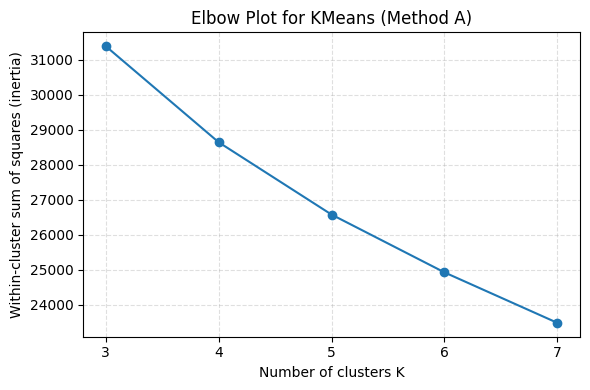

In [9]:
# K-means model selection on the PCA-reduced aggregate features (Method A)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

X_A = Z_A
range_n_clusters = range(3, 8)
sil_A, dbi_A, inertias_A = [], [], []

print("[Method A] K-means model selection:")
for n in range_n_clusters:
    km_A = KMeans(n_clusters=n, random_state=42, n_init=10)
    km_A.fit(X_A)
    labels_A = km_A.predict(X_A)

    s = silhouette_score(X_A, labels_A)
    d = davies_bouldin_score(X_A, labels_A)
    inertias_A.append(km_A.inertia_)
    sil_A.append(s)
    dbi_A.append(d)

    print(f"K={n}: Inertia={km_A.inertia_:.2f}, silhouette={s:.3f}, DBI={d:.3f}")

plt.figure(figsize=(6, 4))
plt.plot(list(range_n_clusters), inertias_A, marker='o')
plt.xticks(list(range_n_clusters))
plt.xlabel('Number of clusters K')
plt.ylabel('Within-cluster sum of squares (inertia)')
plt.title('Elbow Plot for KMeans (Method A)')
plt.grid(alpha=0.4, linestyle='--')
plt.tight_layout()
plt.show()


**Choosing K for Method A.** K=5 gives the highest silhouette score (0.146) of the range tested and a Davies-Bouldin Index (1.855) close to the best value in the set (1.801 at K=6). Since K=5 is essentially the best choice on silhouette and competitive on DBI, it's a defensible pick on the metrics alone — and it also keeps Method A's cluster count aligned with Method B's final K, which makes the two representations easier to compare directly in the agreement analysis below.

## 2. Method B: Transaction-Level SVD + RFM (Recency, Frequency, Monetary)

Rather than aggregating first, Method B engineers features at the transaction level, reduces the sparse categorical feature space with Truncated SVD, then aggregates the reduced representation up to the customer level alongside simple RFM metrics.

**Cyclical time encoding.** Hour, month, and day-of-week are cyclical (23:00 is one hour from 00:00), so treating them as plain integers would make K-means treat the start and end of each cycle as maximally distant. Each is instead encoded as a sine/cosine pair, which places the values on a circle and preserves that adjacency.

In [10]:
df = df.copy()

# Time -> cyclic features
df['hour']  = pd.to_datetime(df['timestamp']).dt.hour.astype('Int8')
df['month'] = pd.to_datetime(df['timestamp']).dt.month.astype('Int8')
df['dow']   = pd.to_datetime(df['timestamp']).dt.dayofweek.astype('Int8')

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['mon_sin']  = np.sin(2 * np.pi * df['month'] / 12)
df['mon_cos']  = np.cos(2 * np.pi * df['month'] / 12)
df['dow_sin']  = np.sin(2 * np.pi * df['dow'] / 7)
df['dow_cos']  = np.cos(2 * np.pi * df['dow'] / 7)


In [11]:
# Signed transaction amount in dollars; missing values treated as zero
df['amt_signed'] = df['amount_cents'].fillna(0).astype('int64') / 100.0


**Feature groups for Method B.**

| Numerical | Purpose |
|---|---|
| `amt_signed` | Core monetary feature (positive = spend, negative = refund) |
| `hour_sin`/`cos`, `mon_sin`/`cos`, `dow_sin`/`cos` | Cyclical time-of-transaction features |

| Categorical | Cardinality | Purpose |
|---|---|---|
| `MCC` | High | Merchant category — the primary driver of lifestyle/purchase-type signal |
| `channel` | Low | Online vs. card-present |
| `entry_mode` | Low | Tap / swipe / key-in |
| `merchant_state` | Medium | Geographic preference |
| `country` | Medium | Domestic vs. international |

`merchant_id` and `merchant_city` are deliberately excluded — their cardinality is high enough that one-hot encoding them would make the feature matrix too sparse and push the clustering toward distinguishing individual stores rather than spending behavior. If store-level identity is needed later, hashing or count-encoding is a better fit than one-hot.

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline

num_cols = ['amt_signed', 'hour_sin', 'hour_cos', 'mon_sin', 'mon_cos', 'dow_sin', 'dow_cos']
cat_cols = ['MCC', 'channel', 'entry_mode', 'merchant_state', 'country']

ct = ColumnTransformer(
    transformers=[
        # with_mean=False preserves sparsity when scaling
        ('num', StandardScaler(with_mean=False), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), cat_cols),
    ],
    sparse_threshold=1.0,
)

# 20 components chosen: they capture ~89% of total variance, balancing
# compression against retained signal (see explained-variance check below).
svd = TruncatedSVD(n_components=20, random_state=42)

pipe = Pipeline([('prep', ct), ('svd', svd)])
X_pca = pipe.fit_transform(df)

explained = svd.explained_variance_ratio_.sum()
print(f"Explained variance (20 comps): {explained:.2%}")
print(f"Transaction-level SVD output shape: {X_pca.shape}")


Explained variance (20 comps): 89.28%
Transaction-level SVD output shape: (24357143, 20)


**Top loadings for the first two SVD components** — the categorical features with the largest positive/negative influence on each latent dimension, used later to help interpret what each component represents.

In [13]:
ct_fitted = pipe.named_steps['prep']
svd_fitted = pipe.named_steps['svd']

raw_feature_names = ct_fitted.get_feature_names_out()
feature_names = np.array([n.replace('num__', '').replace('cat__', '') for n in raw_feature_names])
components = svd_fitted.components_

def get_top_loadings(components, feature_names, n_components=2, top_k=10):
    """Top `top_k` features by absolute loading for each of the first `n_components`."""
    tables = {}
    for i in range(n_components):
        comp = components[i]
        top_idx = np.argsort(np.abs(comp))[::-1][:top_k]
        df_pc = pd.DataFrame({'Feature': feature_names[top_idx], 'Loading': comp[top_idx]})
        df_pc['AbsLoading'] = df_pc['Loading'].abs()
        tables[f'PC{i + 1}'] = df_pc.sort_values('AbsLoading', ascending=False).drop(columns='AbsLoading').reset_index(drop=True)
    return tables

top_tables = get_top_loadings(components, feature_names, n_components=2, top_k=10)
for pc_name, df_pc in top_tables.items():
    print(f"\n=== Top loadings for {pc_name} ===")
    print(df_pc)



=== Top loadings for PC1 ===
                            Feature   Loading
0  country_United States of America  0.477852
1                          hour_cos -0.476378
2              channel_card_present  0.473491
3                        amt_signed  0.381974
4                  entry_mode_swipe  0.354461
5                   entry_mode_chip  0.125620
6                          MCC_5411  0.063982
7                          MCC_5541  0.058894
8                 merchant_state_CA  0.058809
9                          MCC_5499  0.057334

=== Top loadings for PC2 ===
                  Feature   Loading
0                hour_sin  0.652542
1              amt_signed -0.557177
2                hour_cos -0.506000
3                MCC_5411  0.040630
4    channel_card_present -0.036734
5                MCC_5499  0.026592
6                MCC_5541  0.025115
7       entry_mode_online -0.021673
8         country_Unknown -0.021634
9  merchant_state_Unknown -0.021634


A positive loading means a customer's score on that component rises with the original feature (e.g., a high loading on `mcc_5411` pulls a component toward "grocery spending"). A negative loading means the opposite — so a component with a positive loading on one MCC and a negative loading on another is effectively distinguishing between those two behaviors.

PC_1's largest positive weights fall on domestic, card-present transactions with chip entry and higher amounts, plus grocery/fuel MCCs — it captures the intensity of everyday, in-store US spending. PC_2 is dominated by the sinusoidal hour-of-day features with a strong negative loading on transaction amount, so it reflects time-of-day usage patterns more than overall spend level.

### Customer-Level Aggregation

Collapse the transaction-level SVD scores to one row per customer (mean/sum of each component) and combine with simple, interpretable RFM features.

In [14]:
CUSTOMER_ID_COL = 'user_id'

df_pca = pd.DataFrame(X_pca, index=df.index)
df_pca.columns = [f'PC_{i+1}' for i in range(X_pca.shape[1])]
df_pca[CUSTOMER_ID_COL] = df[CUSTOMER_ID_COL]

g_pca = df_pca.groupby(CUSTOMER_ID_COL)
feat_pca = pd.DataFrame(index=g_pca.size().index)
for col in df_pca.columns[:-1]:
    feat_pca[f'{col}_mean'] = g_pca[col].mean()
    feat_pca[f'{col}_sum'] = g_pca[col].sum()

feat_pca.head()


,PC_1_mean,PC_1_sum,PC_2_mean,PC_2_sum,PC_3_mean,PC_3_sum,PC_4_mean,PC_4_sum,PC_5_mean,PC_5_sum,...,PC_16_mean,PC_16_sum,PC_17_mean,PC_17_sum,PC_18_mean,PC_18_sum,PC_19_mean,PC_19_sum,PC_20_mean,PC_20_sum
user_id,,,,,,,,,,,,,,,,,,,,,
0,1.825175,36386.694414,-0.069774,-1391.018323,-0.008884,-177.107987,0.009604,191.471414,-0.007378,-147.094598,...,0.086238,1719.239328,-0.060954,-1215.173077,-0.012387,-246.940179,0.061396,1223.992633,0.081754,1629.857101
1,1.814475,16123.427055,-0.352267,-3130.242902,-0.026976,-239.704307,0.004481,39.817212,-0.011422,-101.495534,...,-0.238018,-2115.027283,0.035822,318.317202,-0.559301,-4969.949021,-0.231210,-2054.528441,0.395714,3516.317995
2,1.249074,52378.649667,0.217655,9127.128117,-0.010810,-453.307515,0.004048,169.736591,-0.007423,-311.261760,...,0.040954,1717.345593,0.014063,589.715743,-0.002598,-108.926041,0.022288,934.620355,0.037267,1562.756441
3,2.065413,20854.479041,-0.544499,-5497.811339,0.027716,279.844849,-0.013687,-138.195225,-0.036624,-369.797078,...,-0.190260,-1921.059748,0.064429,650.536793,-0.429037,-4331.990681,-0.068347,-690.096026,0.327305,3304.799321
4,2.022647,37499.866234,-0.223230,-4138.681688,0.003424,63.489321,0.000533,9.875316,0.003064,56.811824,...,0.080433,1491.224644,-0.056314,-1044.054667,-0.002743,-50.855143,-0.028536,-529.049196,0.045592,845.279685


In [15]:
g_rfm = df.groupby(CUSTOMER_ID_COL, observed=True)

current_time = pd.to_datetime(df['timestamp']).max()
recency    = (current_time - g_rfm['timestamp'].max()).dt.days.rename('Recency_Days')
txn_cnt    = g_rfm.size().rename('Total_Transactions')
total_spend = g_rfm['amt_signed'].sum(min_count=1).rename('Total_Spend')

final_feat = feat_pca.join([recency, txn_cnt, total_spend], how='inner').fillna(0)
final_feat.head()


,PC_1_mean,PC_1_sum,PC_2_mean,PC_2_sum,PC_3_mean,PC_3_sum,PC_4_mean,PC_4_sum,PC_5_mean,PC_5_sum,...,PC_17_sum,PC_18_mean,PC_18_sum,PC_19_mean,PC_19_sum,PC_20_mean,PC_20_sum,Recency_Days,Total_Transactions,Total_Spend
user_id,,,,,,,,,,,,,,,,,,,,,
0,1.825175,36386.694414,-0.069774,-1391.018323,-0.008884,-177.107987,0.009604,191.471414,-0.007378,-147.094598,...,-1215.173077,-0.012387,-246.940179,0.061396,1223.992633,0.081754,1629.857101,0,19936,1620374.41
1,1.814475,16123.427055,-0.352267,-3130.242902,-0.026976,-239.704307,0.004481,39.817212,-0.011422,-101.495534,...,318.317202,-0.559301,-4969.949021,-0.231210,-2054.528441,0.395714,3516.317995,1,8886,716298.26
2,1.249074,52378.649667,0.217655,9127.128117,-0.010810,-453.307515,0.004048,169.736591,-0.007423,-311.261760,...,589.715743,-0.002598,-108.926041,0.022288,934.620355,0.037267,1562.756441,0,41934,1471585.60
3,2.065413,20854.479041,-0.544499,-5497.811339,0.027716,279.844849,-0.013687,-138.195225,-0.036624,-369.797078,...,650.536793,-0.429037,-4331.990681,-0.068347,-690.096026,0.327305,3304.799321,0,10097,1183826.92
4,2.022647,37499.866234,-0.223230,-4138.681688,0.003424,63.489321,0.000533,9.875316,0.003064,56.811824,...,-1044.054667,-0.002743,-50.855143,-0.028536,-529.049196,0.045592,845.279685,0,18540,1798746.67


In [16]:
pca_mean_cols = [c for c in final_feat.columns if c.startswith('PC_') and c.endswith('_mean')]
rfm_cols = ['Recency_Days', 'Total_Transactions', 'Total_Spend']

X_final = final_feat[pca_mean_cols + rfm_cols].values
print("Method B customer-level feature matrix:", X_final.shape)


Method B customer-level feature matrix: (2000, 23)


In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

scaler_final = StandardScaler()
X_final_scaled = scaler_final.fit_transform(X_final)

range_n_clusters = range(3, 8)
silhouette_scores, dbi_scores = [], []

print("[Method B] SVD + RFM model selection:")
for k in range_n_clusters:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_final_scaled)

    sil = silhouette_score(X_final_scaled, labels_k)
    dbi = davies_bouldin_score(X_final_scaled, labels_k)
    silhouette_scores.append(sil)
    dbi_scores.append(dbi)

    print(f"K={k}: silhouette={sil:.3f}, DBI={dbi:.3f}")


[Method B] SVD + RFM model selection:
K=3: silhouette=0.220, DBI=1.895
K=4: silhouette=0.201, DBI=1.894
K=5: silhouette=0.193, DBI=2.025
K=6: silhouette=0.210, DBI=1.719
K=7: silhouette=0.165, DBI=1.860


**Choosing K for Method B.** K=3 has the highest silhouette score (0.220) and K=6 has the lowest DBI (1.719); K=5 is not the statistical optimum on either metric (silhouette 0.193, DBI 2.025). K=5 was chosen anyway, for two practical reasons: five segments is a natural size for a business audience to act on (versus three broad buckets or six overlapping ones), and it keeps this method directly comparable to Method A, which was also fit at K=5. This is a deliberate interpretability trade-off, not a claim that K=5 is the statistically best-separated solution — the cluster-stability checks below test how much that trade-off costs in practice.

In [18]:
OPTIMAL_K = 5
kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
final_feat['Cluster'] = kmeans_final.fit_predict(X_final_scaled)

print("Final KMeans (Method B) fitted with K=5.")


Final KMeans (Method B) fitted with K=5.


In [19]:
# Map numeric clusters to human-readable segment names.
# Labels are assigned by inspecting the RFM profile table below (segment_summary) —
# they are a manual interpretive step, not something K-means produces on its own.
cluster_labels = {
    0: "Elite High-Volume Spenders",
    1: "Recent, Low-Value Trialists",             # low spend, low txn
    2: "Frequent Local In-Person Buyers",          # heavy activity, not elite spend
    3: "Balanced, Card-Present Family Shoppers",   # highest txn count
    4: "Dormant / Churn Risk (Lapsed Buyers)",     # highest recency, largest group
}

final_feat['Segment_Name'] = final_feat['Cluster'].map(cluster_labels)
final_feat.head()


,PC_1_mean,PC_1_sum,PC_2_mean,PC_2_sum,PC_3_mean,PC_3_sum,PC_4_mean,PC_4_sum,PC_5_mean,PC_5_sum,...,PC_18_sum,PC_19_mean,PC_19_sum,PC_20_mean,PC_20_sum,Recency_Days,Total_Transactions,Total_Spend,Cluster,Segment_Name
user_id,,,,,,,,,,,,,,,,,,,,,
0,1.825175,36386.694414,-0.069774,-1391.018323,-0.008884,-177.107987,0.009604,191.471414,-0.007378,-147.094598,...,-246.940179,0.061396,1223.992633,0.081754,1629.857101,0,19936,1620374.41,4,Dormant / Churn Risk (Lapsed Buyers)
1,1.814475,16123.427055,-0.352267,-3130.242902,-0.026976,-239.704307,0.004481,39.817212,-0.011422,-101.495534,...,-4969.949021,-0.231210,-2054.528441,0.395714,3516.317995,1,8886,716298.26,0,Elite High-Volume Spenders
2,1.249074,52378.649667,0.217655,9127.128117,-0.010810,-453.307515,0.004048,169.736591,-0.007423,-311.261760,...,-108.926041,0.022288,934.620355,0.037267,1562.756441,0,41934,1471585.60,4,Dormant / Churn Risk (Lapsed Buyers)
3,2.065413,20854.479041,-0.544499,-5497.811339,0.027716,279.844849,-0.013687,-138.195225,-0.036624,-369.797078,...,-4331.990681,-0.068347,-690.096026,0.327305,3304.799321,0,10097,1183826.92,0,Elite High-Volume Spenders
4,2.022647,37499.866234,-0.223230,-4138.681688,0.003424,63.489321,0.000533,9.875316,0.003064,56.811824,...,-50.855143,-0.028536,-529.049196,0.045592,845.279685,0,18540,1798746.67,4,Dormant / Churn Risk (Lapsed Buyers)


In [20]:
segment_summary = (
    final_feat
    .groupby(['Cluster', 'Segment_Name'], observed=True)
    .agg(
        n_customers        = ('Total_Spend', 'size'),
        mean_recency_days  = ('Recency_Days', 'mean'),
        median_recency     = ('Recency_Days', 'median'),
        mean_txn_count     = ('Total_Transactions', 'mean'),
        median_txn_count   = ('Total_Transactions', 'median'),
        mean_total_spend   = ('Total_Spend', 'mean'),
        median_total_spend = ('Total_Spend', 'median'),
    )
    .sort_values('Cluster')
)

print("--- Method B Segment Summary (RFM by Segment) ---")
print(segment_summary.round(2).to_string())


--- Method B Segment Summary (RFM by Segment) ---
                                                n_customers  mean_recency_days  median_recency  mean_txn_count  median_txn_count  mean_total_spend  median_total_spend
Cluster Segment_Name                                                                                                                                                  
0       Elite High-Volume Spenders                      119              48.70             0.0        13658.82           12944.0         665759.30           519860.60
1       Recent, Low-Value Trialists                     341               0.73             0.0          175.56             121.0           7653.11             5035.50
2       Frequent Local In-Person Buyers                 121              41.02             0.0        13556.62           12155.0         584496.49           466965.85
3       Balanced, Card-Present Family Shoppers          287              68.38             0.0        18311.67     

**Alignment check: segment name vs. RFM data**

| Cluster | Segment Name | Data Justification |
|---|---|---|
| 0 | Elite High-Volume Spenders | Highest mean spend (\$665.8k) and median spend (\$519.9k); high transaction count |
| 1 | Recent, Low-Value Trialists | Lowest recency (0.73 days), lowest spend (\$7.7k), lowest transaction count (176) |
| 2 | Frequent Local In-Person Buyers | High transaction count (13.6k) but lower spend than other high-activity segments |
| 3 | Balanced, Card-Present Family Shoppers | Highest transaction count (18.3k); high spend (\$657.9k); average recency (~68 days) |
| 4 | Dormant / Churn Risk (Lapsed Buyers) | Largest segment (1,132 customers); highest recency (90.7 days) despite historically high spend |

The "Local/In-Person" and "Family Shopper" framing for clusters 2 and 3 is inferred from the MCC and channel SVD loadings, not from RFM alone — RFM only supports the volume/recency/spend part of each label.

## 3. Algorithm Comparison and Stability

K-means is the primary method above. This section checks that choice against two alternatives (Gaussian Mixture Models, Spectral Clustering) and tests how stable the K-means solution is across random seeds and against the Method A representation.

In [21]:
from sklearn.mixture import GaussianMixture
from sklearn.cluster import SpectralClustering
from sklearn.metrics import adjusted_rand_score

K = 5

gmm = GaussianMixture(n_components=K, random_state=42)
labels_gmm = gmm.fit_predict(X_final_scaled)
sil_gmm = silhouette_score(X_final_scaled, labels_gmm)
ari_km_gmm = adjusted_rand_score(final_feat['Cluster'], labels_gmm)
print(f"GMM (K={K}) silhouette: {sil_gmm:.3f}, ARI vs KMeans: {ari_km_gmm:.3f}")

spectral = SpectralClustering(
    n_clusters=K, affinity='nearest_neighbors', n_neighbors=10,
    assign_labels='kmeans', random_state=42,
)
labels_spec = spectral.fit_predict(X_final_scaled)
sil_spec = silhouette_score(X_final_scaled, labels_spec)
ari_km_spec = adjusted_rand_score(final_feat['Cluster'], labels_spec)
print(f"Spectral (K={K}) silhouette: {sil_spec:.3f}, ARI vs KMeans: {ari_km_spec:.3f}")


GMM (K=5) silhouette: 0.106, ARI vs KMeans: 0.557
Spectral (K=5) silhouette: 0.174, ARI vs KMeans: 0.576


K-means's silhouette score (0.193) sits between GMM (0.106) and Spectral (0.174), but agreement with the alternative methods is only moderate (ARI 0.557 vs. GMM, 0.576 vs. Spectral) — the three algorithms are finding related but not identical structure. K-means was kept as the primary method for its simplicity, determinism, and direct compatibility with the centroid-based interpretation used throughout the rest of the analysis.

In [22]:
# Stability check: how consistent is the K-means solution across random seeds?
K = 5
n_runs = 10
all_labels = []

print(f"[Stability Check] KMeans (K={K}) across {n_runs} random seeds:")
for seed in range(n_runs):
    km = KMeans(n_clusters=K, random_state=seed, n_init=10)
    all_labels.append(km.fit_predict(X_final_scaled))

pairwise_ari = [
    adjusted_rand_score(all_labels[i], all_labels[j])
    for i in range(n_runs) for j in range(i + 1, n_runs)
]
print(f"Mean pairwise ARI across seeds: {np.mean(pairwise_ari):.3f} (std: {np.std(pairwise_ari):.3f})")


[Stability Check] KMeans (K=5) across 10 random seeds:
Mean pairwise ARI across seeds: 0.674 (std: 0.127)


In [23]:
# Method A vs. Method B: do the two feature representations agree on customer segments?
K = 5
km_A = KMeans(n_clusters=K, random_state=42, n_init=10)
labels_A = km_A.fit_predict(Z_A)

km_B = KMeans(n_clusters=K, random_state=42, n_init=10)
labels_B = km_B.fit_predict(X_final_scaled)

ari_AB = adjusted_rand_score(labels_A, labels_B)
print(f"ARI between Method A and Method B clusters (K={K}): {ari_AB:.3f}")


ARI between Method A and Method B clusters (K=5): 0.023


An ARI of 0.023 between Method A and Method B is close to what two *random* clusterings would produce — the two representations are essentially uncorrelated. This is a genuine finding, not a modeling failure: it shows that transaction-level behavioral signal (channel, timing, merchant category, sequencing) captures something about customer lifestyle that simple customer-level aggregates (total spend, average transaction size, refund rate) do not. Method B is used as the primary representation for that reason.

## 4. Segment Interpretation & Visuals

Individual points overlap substantially here — expected when projecting a 23-dimensional space into two — but the segment centroids are still visibly separated. Elite High-Volume Spenders and Balanced Family Shoppers sit offset from the Trialists, while Dormant/Churn-Risk customers form a smaller, tighter cloud driven by their recency and category mix.

In [24]:
# Feature means per cluster and PCA-component interpretation
interpretable_cols = ['Recency_Days', 'Total_Spend', 'Total_Transactions']
cluster_profiles_summary = final_feat.groupby('Cluster')[interpretable_cols].mean()
print("High-level RFM averages by cluster:")
print(cluster_profiles_summary)

svd_components = pipe['svd'].components_
ohe_feature_names = pipe['prep'].named_transformers_['cat'].get_feature_names_out(cat_cols)
all_feature_names = num_cols + list(ohe_feature_names)
component_weights = pd.DataFrame(svd_components, columns=all_feature_names)

print("\nTop features defining PC_1 and PC_2:")
for i in [0, 1]:
    weights = component_weights.iloc[i].sort_values(ascending=False)
    print(f"\nPC_{i + 1}:")
    print(f"  Positively loaded: {weights.head(3).index.tolist()}")
    print(f"  Negatively loaded: {weights.tail(3).index.tolist()}")


High-level RFM averages by cluster:
         Recency_Days    Total_Spend  Total_Transactions
Cluster                                                 
0           48.697479  665759.301681        13658.823529
1            0.730205    7653.108446          175.560117
2           41.024793  584496.490165        13556.619835
3           68.383275  657926.901010        18311.672474
4           90.662544  635585.349602        13936.462898

Top features defining PC_1 and PC_2:

PC_1:
  Positively loaded: ['country_United States of America', 'channel_card_present', 'amt_signed']
  Negatively loaded: ['dow_sin', 'mon_sin', 'hour_cos']

PC_2:
  Positively loaded: ['hour_sin', 'MCC_5411', 'MCC_5499']
  Negatively loaded: ['channel_card_present', 'hour_cos', 'amt_signed']


### Feature Lift Heatmap

Feature lift (a cluster's mean value divided by the population mean) shows which features distinguish each segment most, independent of the raw scale of each feature.

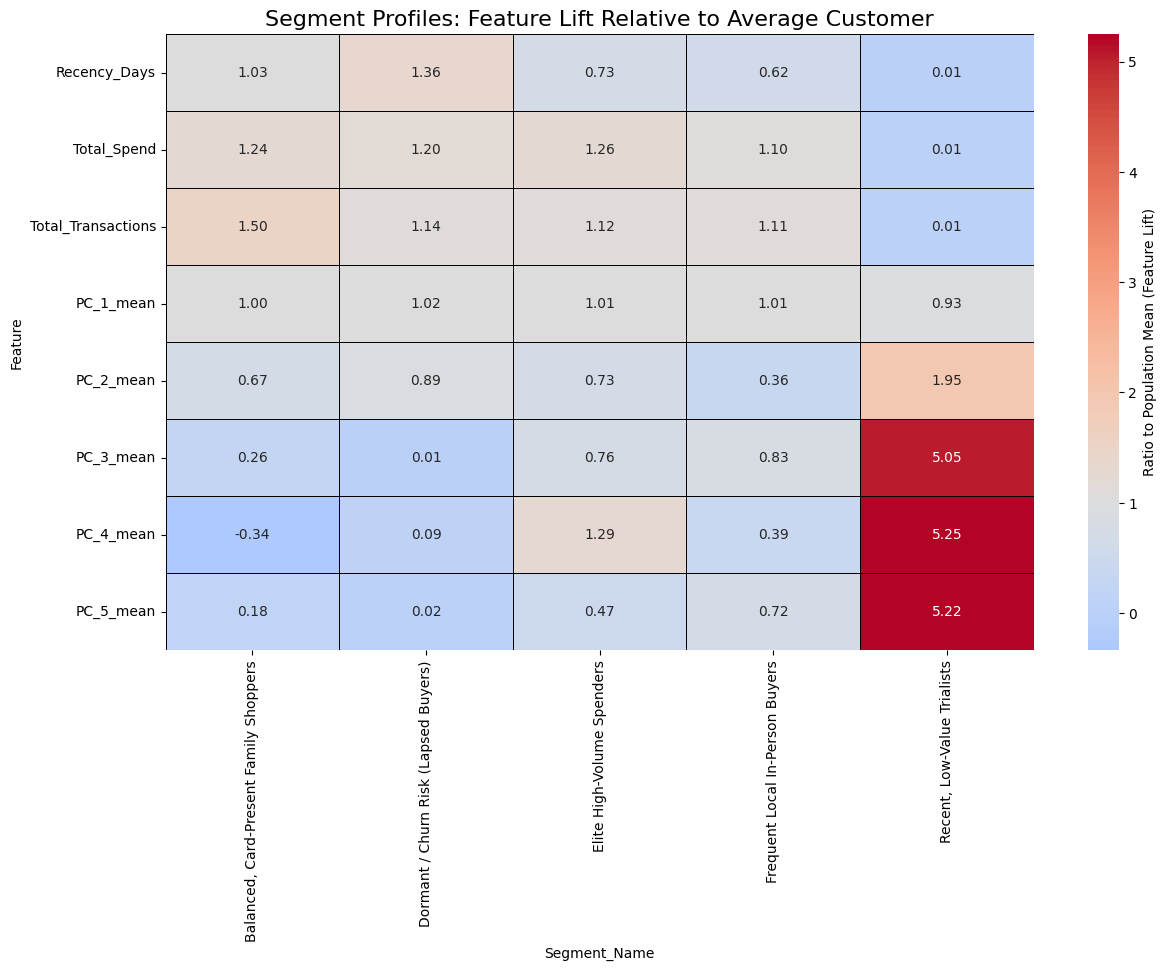

In [25]:
features_to_analyze = ['Recency_Days', 'Total_Spend', 'Total_Transactions'] + final_feat.filter(like='PC_').columns.tolist()
overall_mean = final_feat[features_to_analyze].mean()
cluster_profiles_raw = final_feat.groupby('Segment_Name')[features_to_analyze].mean()
cluster_profiles_lift = cluster_profiles_raw.div(overall_mean, axis=1)

plot_features = ['Recency_Days', 'Total_Spend', 'Total_Transactions'] + \
    [c for c in cluster_profiles_lift.columns if c.endswith('_mean')][:5]

plt.figure(figsize=(14, 8))
sns.heatmap(
    cluster_profiles_lift[plot_features].T,
    annot=True, fmt=".2f", cmap="coolwarm", center=1.0,
    linewidths=.5, linecolor='black',
    cbar_kws={'label': 'Ratio to Population Mean (Feature Lift)'},
)
plt.title('Segment Profiles: Feature Lift Relative to Average Customer', fontsize=16)
plt.ylabel('Feature')
plt.yticks(rotation=0)
plt.show()


### RFM Distributions

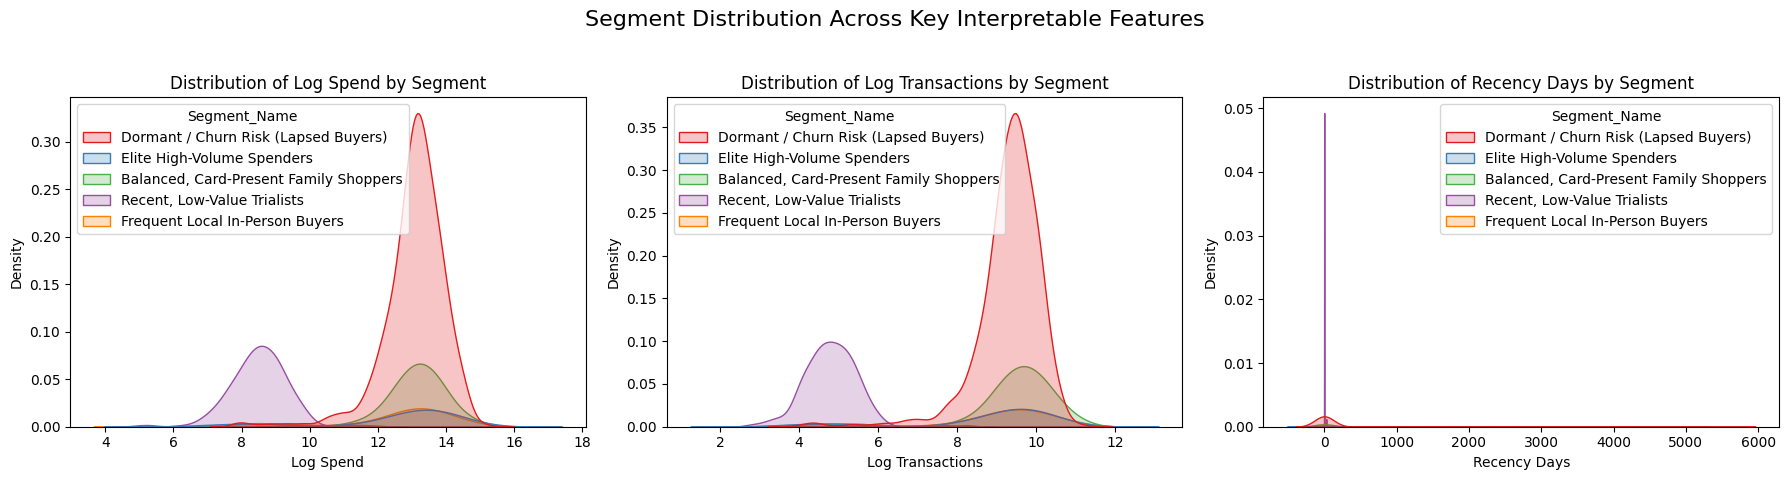

In [26]:
# --- Select the key RFM features for plotting ---
rfm_vars = ['Total_Spend', 'Total_Transactions', 'Recency_Days']

# To handle the massive difference in scale (like Cluster 4's low spend vs. others),
# it's best to use a log scale for highly skewed monetary/frequency variables.
# We apply log1p to Total_Spend and Total_Transactions for better visualization.
df_plot = final_feat.copy()
df_plot['Log_Spend'] = np.log1p(df_plot['Total_Spend'])
df_plot['Log_Transactions'] = np.log1p(df_plot['Total_Transactions'])
plot_vars = ['Log_Spend', 'Log_Transactions', 'Recency_Days']
nice_labels = {
    'Log_Spend': 'log(1 + Total Spend)',
    'Log_Transactions': 'log(1 + Total Transactions)',
    'Recency_Days': 'Recency (Days)'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Segment Distribution Across Key Interpretable Features', fontsize=16)

# ======================================
# KDE plot -- distributions comparison

for i, var in enumerate(plot_vars):
    # Use Kernel Density Estimate (KDE) plots to compare distributions
    sns.kdeplot(
        data=df_plot,
        x=var,
        hue='Segment_Name',
        palette='Set1',
        fill=True,
        ax=axes[i]
    )
    axes[i].set_title(f'Distribution of {var.replace("_", " ")} by Segment')
    axes[i].set_xlabel(var.replace('_', ' '))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### PCA Segment Visualization

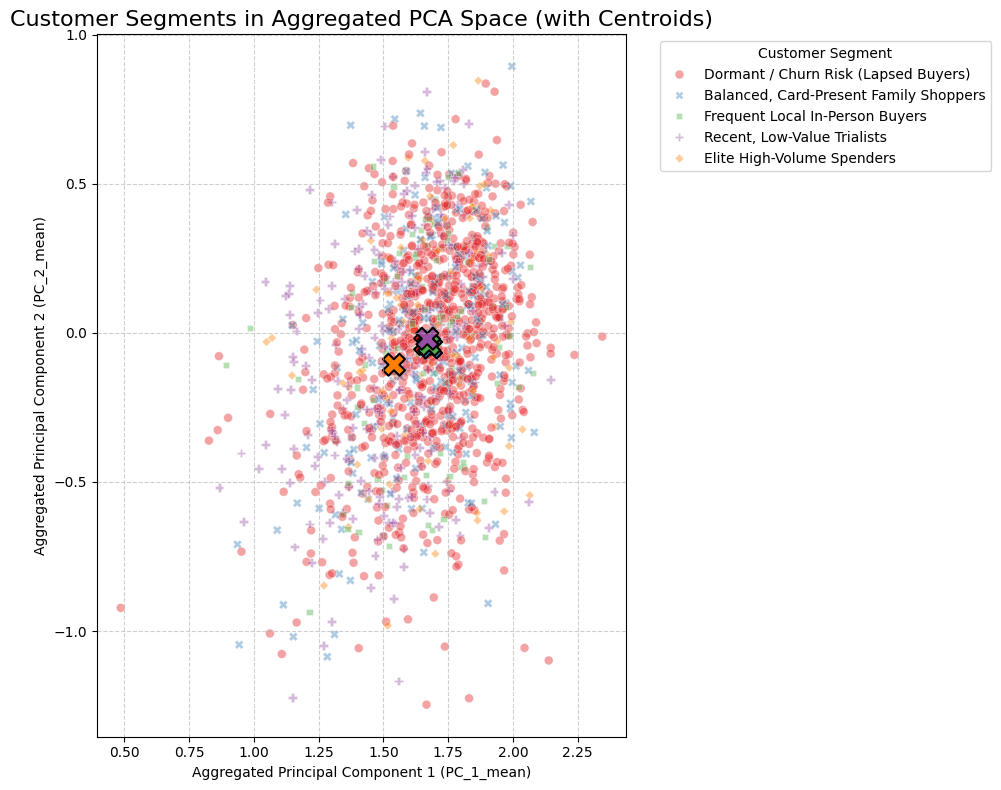

In [27]:
N_SAMPLE = 1500
plot_df = final_feat.sample(n=N_SAMPLE, random_state=42) if len(final_feat) > N_SAMPLE else final_feat.copy()

centroids = (
    final_feat.groupby('Segment_Name')[['PC_1_mean', 'PC_2_mean']].mean().reset_index()
)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=plot_df, x='PC_1_mean', y='PC_2_mean',
    hue='Segment_Name', style='Segment_Name', palette='Set1', s=40, alpha=0.4,
)
sns.scatterplot(
    data=centroids, x='PC_1_mean', y='PC_2_mean',
    hue='Segment_Name', palette='Set1', s=250, marker='X',
    edgecolor='black', linewidth=1.5, legend=False,
)
plt.title('Customer Segments in Aggregated PCA Space (with Centroids)', fontsize=16)
plt.xlabel('Aggregated Principal Component 1 (PC_1_mean)')
plt.ylabel('Aggregated Principal Component 2 (PC_2_mean)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Customer Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### Merchant-Category Diversity by Segment

Shannon entropy over each customer's MCC distribution measures spending diversity (high = spread across many categories, low = concentrated in a few); top-category share measures concentration directly.

In [28]:
from scipy.stats import entropy

df_mcc_counts = df.groupby([CUSTOMER_ID_COL, 'MCC']).size().reset_index(name='MCC_Count')
df_total_counts = df.groupby(CUSTOMER_ID_COL).size().reset_index(name='Total_Count')
df_mcc_counts = pd.merge(df_mcc_counts, df_total_counts, on=CUSTOMER_ID_COL)
df_mcc_counts['P_MCC'] = df_mcc_counts['MCC_Count'] / df_mcc_counts['Total_Count']

mcc_concentration = df_mcc_counts.loc[
    df_mcc_counts.groupby(CUSTOMER_ID_COL)['P_MCC'].idxmax()
][[CUSTOMER_ID_COL, 'P_MCC']].rename(columns={'P_MCC': 'Top_MCC_Concentration'})

def calculate_entropy(probabilities):
    return entropy(probabilities, base=2)

mcc_diversity = df_mcc_counts.groupby(CUSTOMER_ID_COL)['P_MCC'].apply(calculate_entropy).rename('Spending_Diversity_Index')

final_feat['Top_MCC_Concentration'] = mcc_concentration.set_index(CUSTOMER_ID_COL)['Top_MCC_Concentration']
final_feat['Spending_Diversity_Index'] = mcc_diversity
final_feat = final_feat.fillna(0)

mcc_profile = final_feat.groupby('Segment_Name').agg({
    'Top_MCC_Concentration': 'mean',
    'Spending_Diversity_Index': 'mean',
}).sort_values('Top_MCC_Concentration', ascending=False)

print("--- MCC Feature Profile by Segment ---")
print(mcc_profile)


--- MCC Feature Profile by Segment ---
                                        Top_MCC_Concentration  \
Segment_Name                                                    
Balanced, Card-Present Family Shoppers               0.301249   
Recent, Low-Value Trialists                          0.260748   
Elite High-Volume Spenders                           0.221977   
Frequent Local In-Person Buyers                      0.220695   
Dormant / Churn Risk (Lapsed Buyers)                 0.212809   

                                        Spending_Diversity_Index  
Segment_Name                                                      
Balanced, Card-Present Family Shoppers                  3.641730  
Recent, Low-Value Trialists                             3.569995  
Elite High-Volume Spenders                              3.962919  
Frequent Local In-Person Buyers                         4.008971  
Dormant / Churn Risk (Lapsed Buyers)                    4.099795  


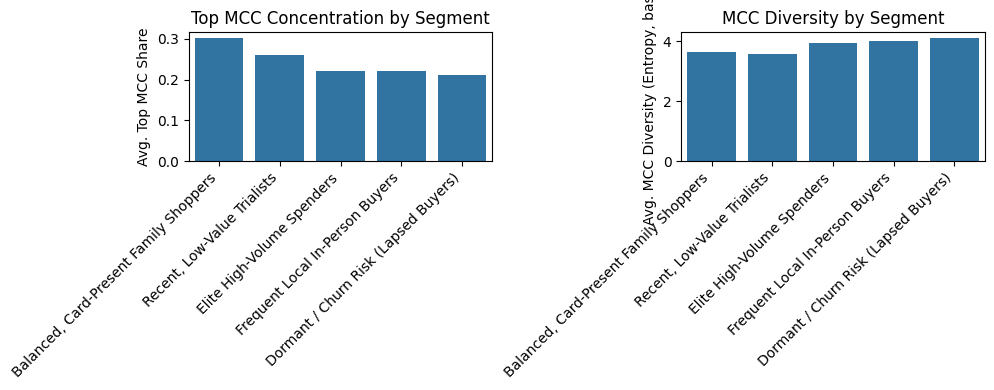

In [29]:
mcc_plot = mcc_profile.reset_index()

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.barplot(data=mcc_plot, x='Segment_Name', y='Top_MCC_Concentration')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Avg. Top MCC Share')
plt.xlabel('')
plt.title('Top MCC Concentration by Segment')

plt.subplot(1, 2, 2)
sns.barplot(data=mcc_plot, x='Segment_Name', y='Spending_Diversity_Index')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Avg. MCC Diversity (Entropy, base 2)')
plt.xlabel('')
plt.title('MCC Diversity by Segment')

plt.tight_layout()
plt.show()


## Business Interpretation

The five segments form a spectrum of card usage that maps to distinct engagement strategies:

- **Recent, Low-Value Trialists** show very recent but low-volume activity — consistent with onboarding or light product testing. Natural targets for low-risk activation campaigns: welcome offers, usage reminders, small bonuses for early recurring purchases.
- **Frequent Local In-Person Buyers** and **Balanced, Card-Present Family Shoppers** represent heavy everyday usage — the former concentrated in local, card-present spending, the latter spread across a wider set of household categories. Both respond well to everyday-spend reinforcement: local merchant offers, grocery/fuel rewards, family-oriented benefits.
- **Elite High-Volume Spenders** sit at the extreme of both frequency and monetary value, with a relatively focused category profile. Candidates for premium servicing: enhanced rewards, tailored category bonuses, personalized relationship management.
- **Dormant / Churn Risk** customers are historically valuable but currently inactive, with long recency and broad past usage. Suitable for targeted win-back experiments — reactivation offers, fee waivers, check-in outreach — where incentive cost gets weighed against prior lifetime value.

## 5. Geographic Analysis

In [30]:
df_merged = pd.merge(
    df,
    final_feat[['Segment_Name']],
    left_on=CUSTOMER_ID_COL,
    right_index=True,
    how='left',
)
df_merged = df_merged[df_merged['merchant_state'].notna()]
df_merged = df_merged[df_merged['merchant_state'].str.len() == 2]
print(df_merged.shape)


(21503860, 29)


In [31]:
import plotly.express as px

TARGET_SEGMENT = "Elite High-Volume Spenders"

df_geo_overall = (
    df_merged.groupby('merchant_state', observed=True)['amt_signed']
    .sum().reset_index(name='Overall_State_Spend')
)

fig_overall = px.choropleth(
    df_geo_overall, locations='merchant_state', locationmode="USA-states",
    color='Overall_State_Spend', scope="usa", color_continuous_scale="Viridis",
    title='Total Transaction Spend by US State (All Customers)',
)
fig_overall.show()

df_geo_segment = (
    df_merged.groupby(['merchant_state', 'Segment_Name'], observed=True)['amt_signed']
    .sum().reset_index(name='Total_Spend_USD')
)
df_segment_target = df_geo_segment[df_geo_segment['Segment_Name'] == TARGET_SEGMENT].copy()

fig_segment_raw = px.choropleth(
    df_segment_target, locations='merchant_state', locationmode="USA-states",
    color='Total_Spend_USD', scope="usa", color_continuous_scale="Reds",
    title=f'Geographic Spending (Raw $) for Segment: {TARGET_SEGMENT}',
)
fig_segment_raw.show()

df_segment_share = df_segment_target.merge(df_geo_overall, on='merchant_state', how='inner')
df_segment_share['Segment_Share'] = df_segment_share['Total_Spend_USD'] / df_segment_share['Overall_State_Spend']

fig_segment_share = px.choropleth(
    df_segment_share, locations='merchant_state', locationmode="USA-states",
    color='Segment_Share', scope="usa", color_continuous_scale="Viridis",
    title=f'Segment Share of State Spend for: {TARGET_SEGMENT}',
)
fig_segment_share.show()


A few states show noticeably higher shares of Elite High-Volume Spenders than the national background. In practice, geographic outliers like these should be treated as hypotheses, not conclusions — worth validating against sample coverage or local merchant mix before they drive regional strategy.

## 6. Temporal Evolution: Five-Year Window Analysis

Re-runs the Method B pipeline independently within consecutive five-year windows, then aligns each window's clusters to the previous window's by centroid cosine similarity, so segment migration can be tracked over time despite K-means's arbitrary cluster numbering.

In [32]:
OPTIMAL_K = 5
n_svd_components = 20
num_cols = ['amt_signed', 'hour_sin', 'hour_cos', 'mon_sin', 'mon_cos', 'dow_sin', 'dow_cos']
cat_cols = ['MCC', 'channel', 'entry_mode', 'merchant_state', 'country']

df['timestamp'] = pd.to_datetime(df['timestamp'])
min_date, max_date = df['timestamp'].min(), df['timestamp'].max()

window_map = {}
current_start = min_date
window_number = 1
while current_start < max_date:
    current_end = min(current_start + pd.DateOffset(years=5), max_date)
    window_map[f"W{window_number} ({current_start.year}-{current_end.year})"] = (current_start, current_end)
    current_start = current_end
    window_number += 1
    if current_end == max_date:
        break

window_names = list(window_map.keys())
print("--- Defined 5-Year Time Windows ---")
for name, (start, end) in window_map.items():
    print(f"{name}: {start.date()} to {end.date()}")


--- Defined 5-Year Time Windows ---
W1 (1991-1996): 1991-01-02 to 1996-01-02
W2 (1996-2001): 1996-01-02 to 2001-01-02
W3 (2001-2006): 2001-01-02 to 2006-01-02
W4 (2006-2011): 2006-01-02 to 2011-01-02
W5 (2011-2016): 2011-01-02 to 2016-01-02
W6 (2016-2020): 2016-01-02 to 2020-02-28


In [33]:
from sklearn.metrics.pairwise import cosine_similarity

all_cluster_labels, all_centroids, all_features = {}, {}, {}

ct = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(with_mean=False), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), cat_cols),
    ],
    sparse_threshold=1.0,
)
svd = TruncatedSVD(n_components=n_svd_components, random_state=42)
pipe = Pipeline([('prep', ct), ('svd', svd)])

for name, (start, end) in window_map.items():
    print(f"\n--- Processing {name} ---")
    df_w = df[(df['timestamp'] >= start) & (df['timestamp'] < end)].copy()

    if df_w.empty or df_w[CUSTOMER_ID_COL].nunique() < 50:
        print("Skipping: insufficient customer data for segmentation.")
        continue

    df_w['hour']  = df_w['timestamp'].dt.hour.astype('Int8')
    df_w['month'] = df_w['timestamp'].dt.month.astype('Int8')
    df_w['dow']   = df_w['timestamp'].dt.dayofweek.astype('Int8')
    df_w['hour_sin'] = np.sin(2 * np.pi * df_w['hour'] / 24)
    df_w['hour_cos'] = np.cos(2 * np.pi * df_w['hour'] / 24)
    df_w['mon_sin']  = np.sin(2 * np.pi * df_w['month'] / 12)
    df_w['mon_cos']  = np.cos(2 * np.pi * df_w['month'] / 12)
    df_w['dow_sin']  = np.sin(2 * np.pi * df_w['dow'] / 7)
    df_w['dow_cos']  = np.cos(2 * np.pi * df_w['dow'] / 7)
    df_w['amt_signed'] = df_w['amount_cents'].fillna(0).astype('int64') / 100.0

    X_pca_w = pipe.fit_transform(df_w)

    df_pca_w = pd.DataFrame(X_pca_w, index=df_w.index)
    df_pca_w.columns = [f'PC_{i+1}' for i in range(X_pca_w.shape[1])]
    df_pca_w[CUSTOMER_ID_COL] = df_w[CUSTOMER_ID_COL]

    g_pca_w = df_pca_w.groupby(CUSTOMER_ID_COL)
    feat_pca_w = pd.DataFrame(index=g_pca_w.size().index)
    for col in df_pca_w.columns[:-1]:
        feat_pca_w[f'{col}_mean'] = g_pca_w[col].mean()

    g_rfm_w = df_w.groupby(CUSTOMER_ID_COL, observed=True)
    current_time_w = df_w['timestamp'].max()
    recency_w = (current_time_w - g_rfm_w['timestamp'].max()).dt.days.rename('Recency_Days')
    txn_cnt_w = g_rfm_w.size().rename('Total_Transactions')
    total_spend_w = g_rfm_w['amt_signed'].sum(min_count=1).rename('Total_Spend')

    feat_w = feat_pca_w.join([recency_w, txn_cnt_w, total_spend_w], how='inner').fillna(0)

    scaler_w = StandardScaler()
    X_final_scaled_w = scaler_w.fit_transform(feat_w.values)

    kmeans_w = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
    labels_w = kmeans_w.fit_predict(X_final_scaled_w)

    feat_w['Cluster'] = labels_w
    all_cluster_labels[name] = feat_w[['Cluster']].reset_index()
    all_centroids[name] = kmeans_w.cluster_centers_
    all_features[name] = feat_w.copy()

    print(f"Segmented {feat_w.shape[0]} customers into {OPTIMAL_K} clusters.")



--- Processing W1 (1991-1996) ---
Skipping: insufficient customer data for segmentation.

--- Processing W2 (1996-2001) ---
Segmented 227 customers into 5 clusters.

--- Processing W3 (2001-2006) ---
Segmented 834 customers into 5 clusters.

--- Processing W4 (2006-2011) ---
Segmented 1426 customers into 5 clusters.

--- Processing W5 (2011-2016) ---
Segmented 1543 customers into 5 clusters.

--- Processing W6 (2016-2020) ---
Segmented 1964 customers into 5 clusters.


**Note:** the earliest window (1991-1996) is skipped — fewer than 50 customers had transaction history in that period, too few to segment reliably.


--- Segment Migration: W2 (1996-2001) -> W3 (2001-2006) ---
Cluster_W2      1     2      4
Cluster_W1                    
0           0.000  0.00  1.000
1           0.000  0.00  1.000
2           0.068  0.08  0.852
3           0.400  0.00  0.600
4           0.000  0.00  1.000


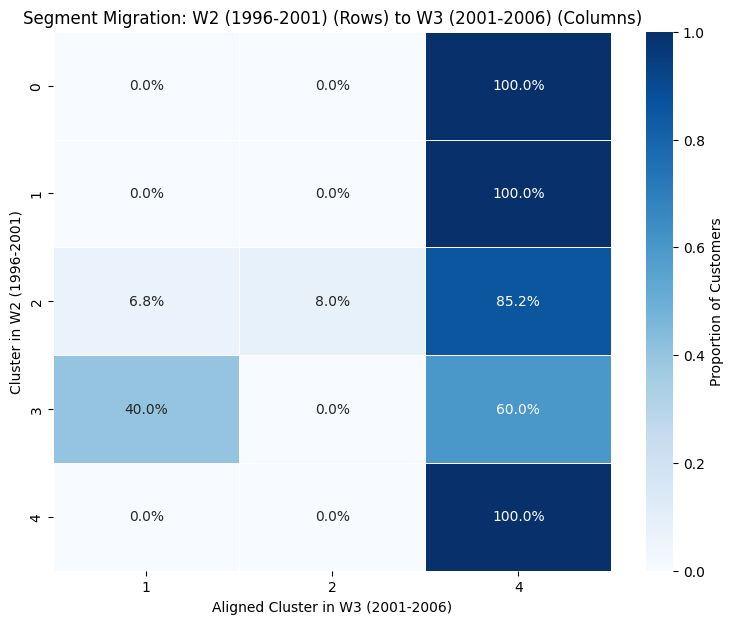


--- Segment Migration: W3 (2001-2006) -> W4 (2006-2011) ---
Cluster_W2      1      2      4
Cluster_W1                     
0           0.607  0.304  0.089
1           0.000  1.000  0.000
2           0.671  0.242  0.087
3           0.571  0.143  0.286
4           0.750  0.250  0.000


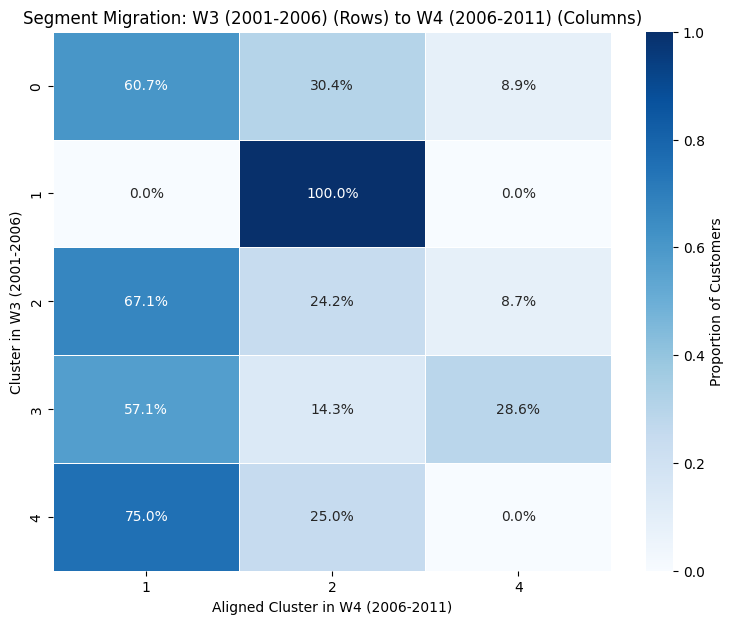


--- Segment Migration: W4 (2006-2011) -> W5 (2011-2016) ---
Cluster_W2      0      3      4
Cluster_W1                     
0           0.145  0.003  0.852
1           0.000  0.000  1.000
2           0.921  0.079  0.000
3           0.946  0.054  0.000
4           0.487  0.436  0.077


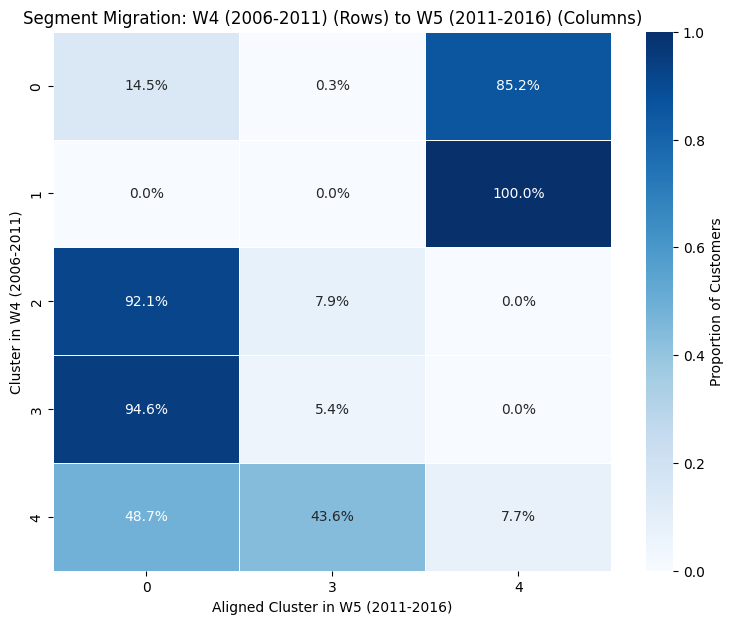


--- Segment Migration: W5 (2011-2016) -> W6 (2016-2020) ---
Cluster_W2      0      1      3      4
Cluster_W1                            
0           0.929  0.013  0.026  0.032
1           0.001  0.924  0.075  0.000
2           0.000  0.500  0.500  0.000
3           0.012  0.423  0.565  0.000
4           0.017  0.418  0.068  0.497


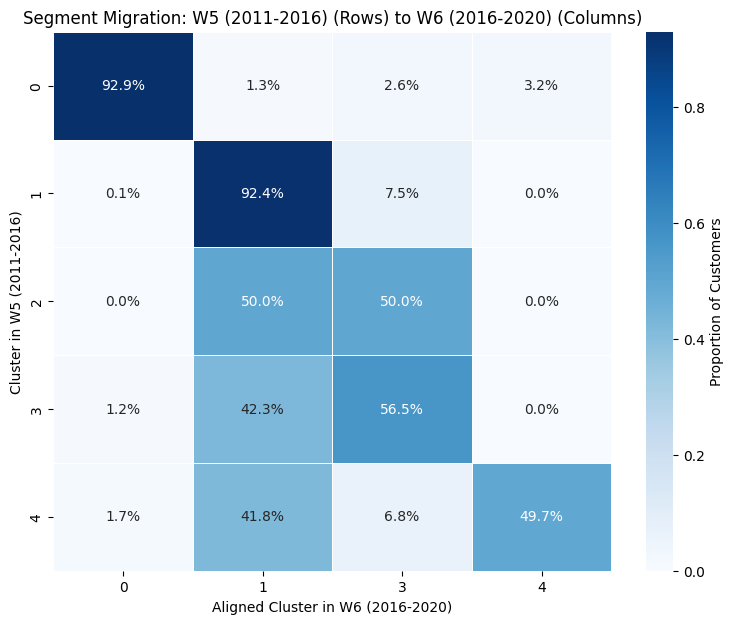

In [34]:
# Align consecutive windows' clusters by centroid cosine similarity, then build a
# row-normalized transition matrix showing where each W1 cluster's customers ended up in W2.
processed_windows = [name for name in window_names if name in all_centroids]

for i in range(len(processed_windows) - 1):
    w1_name, w2_name = processed_windows[i], processed_windows[i + 1]
    centroids_w1, centroids_w2 = all_centroids[w1_name], all_centroids[w2_name]
    labels_w1, labels_w2 = all_cluster_labels[w1_name], all_cluster_labels[w2_name]

    similarity_matrix = cosine_similarity(centroids_w1, centroids_w2)
    w2_to_w1 = {j: int(np.argmax(similarity_matrix[:, j])) for j in range(similarity_matrix.shape[1])}
    labels_w2['Aligned_Cluster'] = labels_w2['Cluster'].map(w2_to_w1)

    df_migration = pd.merge(
        labels_w1.rename(columns={'Cluster': 'Cluster_W1'}),
        labels_w2[['user_id', 'Aligned_Cluster']].rename(columns={'Aligned_Cluster': 'Cluster_W2'}),
        on='user_id', how='inner',
    )

    transition_table = pd.crosstab(df_migration['Cluster_W1'], df_migration['Cluster_W2'], normalize='index')
    print(f"\n--- Segment Migration: {w1_name} -> {w2_name} ---")
    print(transition_table.round(3).to_string())

    plt.figure(figsize=(9, 7))
    sns.heatmap(transition_table, annot=True, fmt=".1%", cmap="Blues", linewidths=.5,
                cbar_kws={'label': 'Proportion of Customers'})
    plt.title(f'Segment Migration: {w1_name} (Rows) to {w2_name} (Columns)')
    plt.xlabel(f'Aligned Cluster in {w2_name}')
    plt.ylabel(f'Cluster in {w1_name}')
    plt.show()


Across the four transition periods, earlier windows show segments merging and splitting more freely — a sign that spending patterns were still forming, or that the data was thinner. By the most recent pair (W5→W6), two segments show over 90% row-wise persistence on the diagonal, with smaller segments feeding into these dominant groups rather than the reverse.

Generating 4 transition plots: [('W2 (1996-2001)', 'W3 (2001-2006)'), ('W3 (2001-2006)', 'W4 (2006-2011)'), ('W4 (2006-2011)', 'W5 (2011-2016)'), ('W5 (2011-2016)', 'W6 (2016-2020)')]



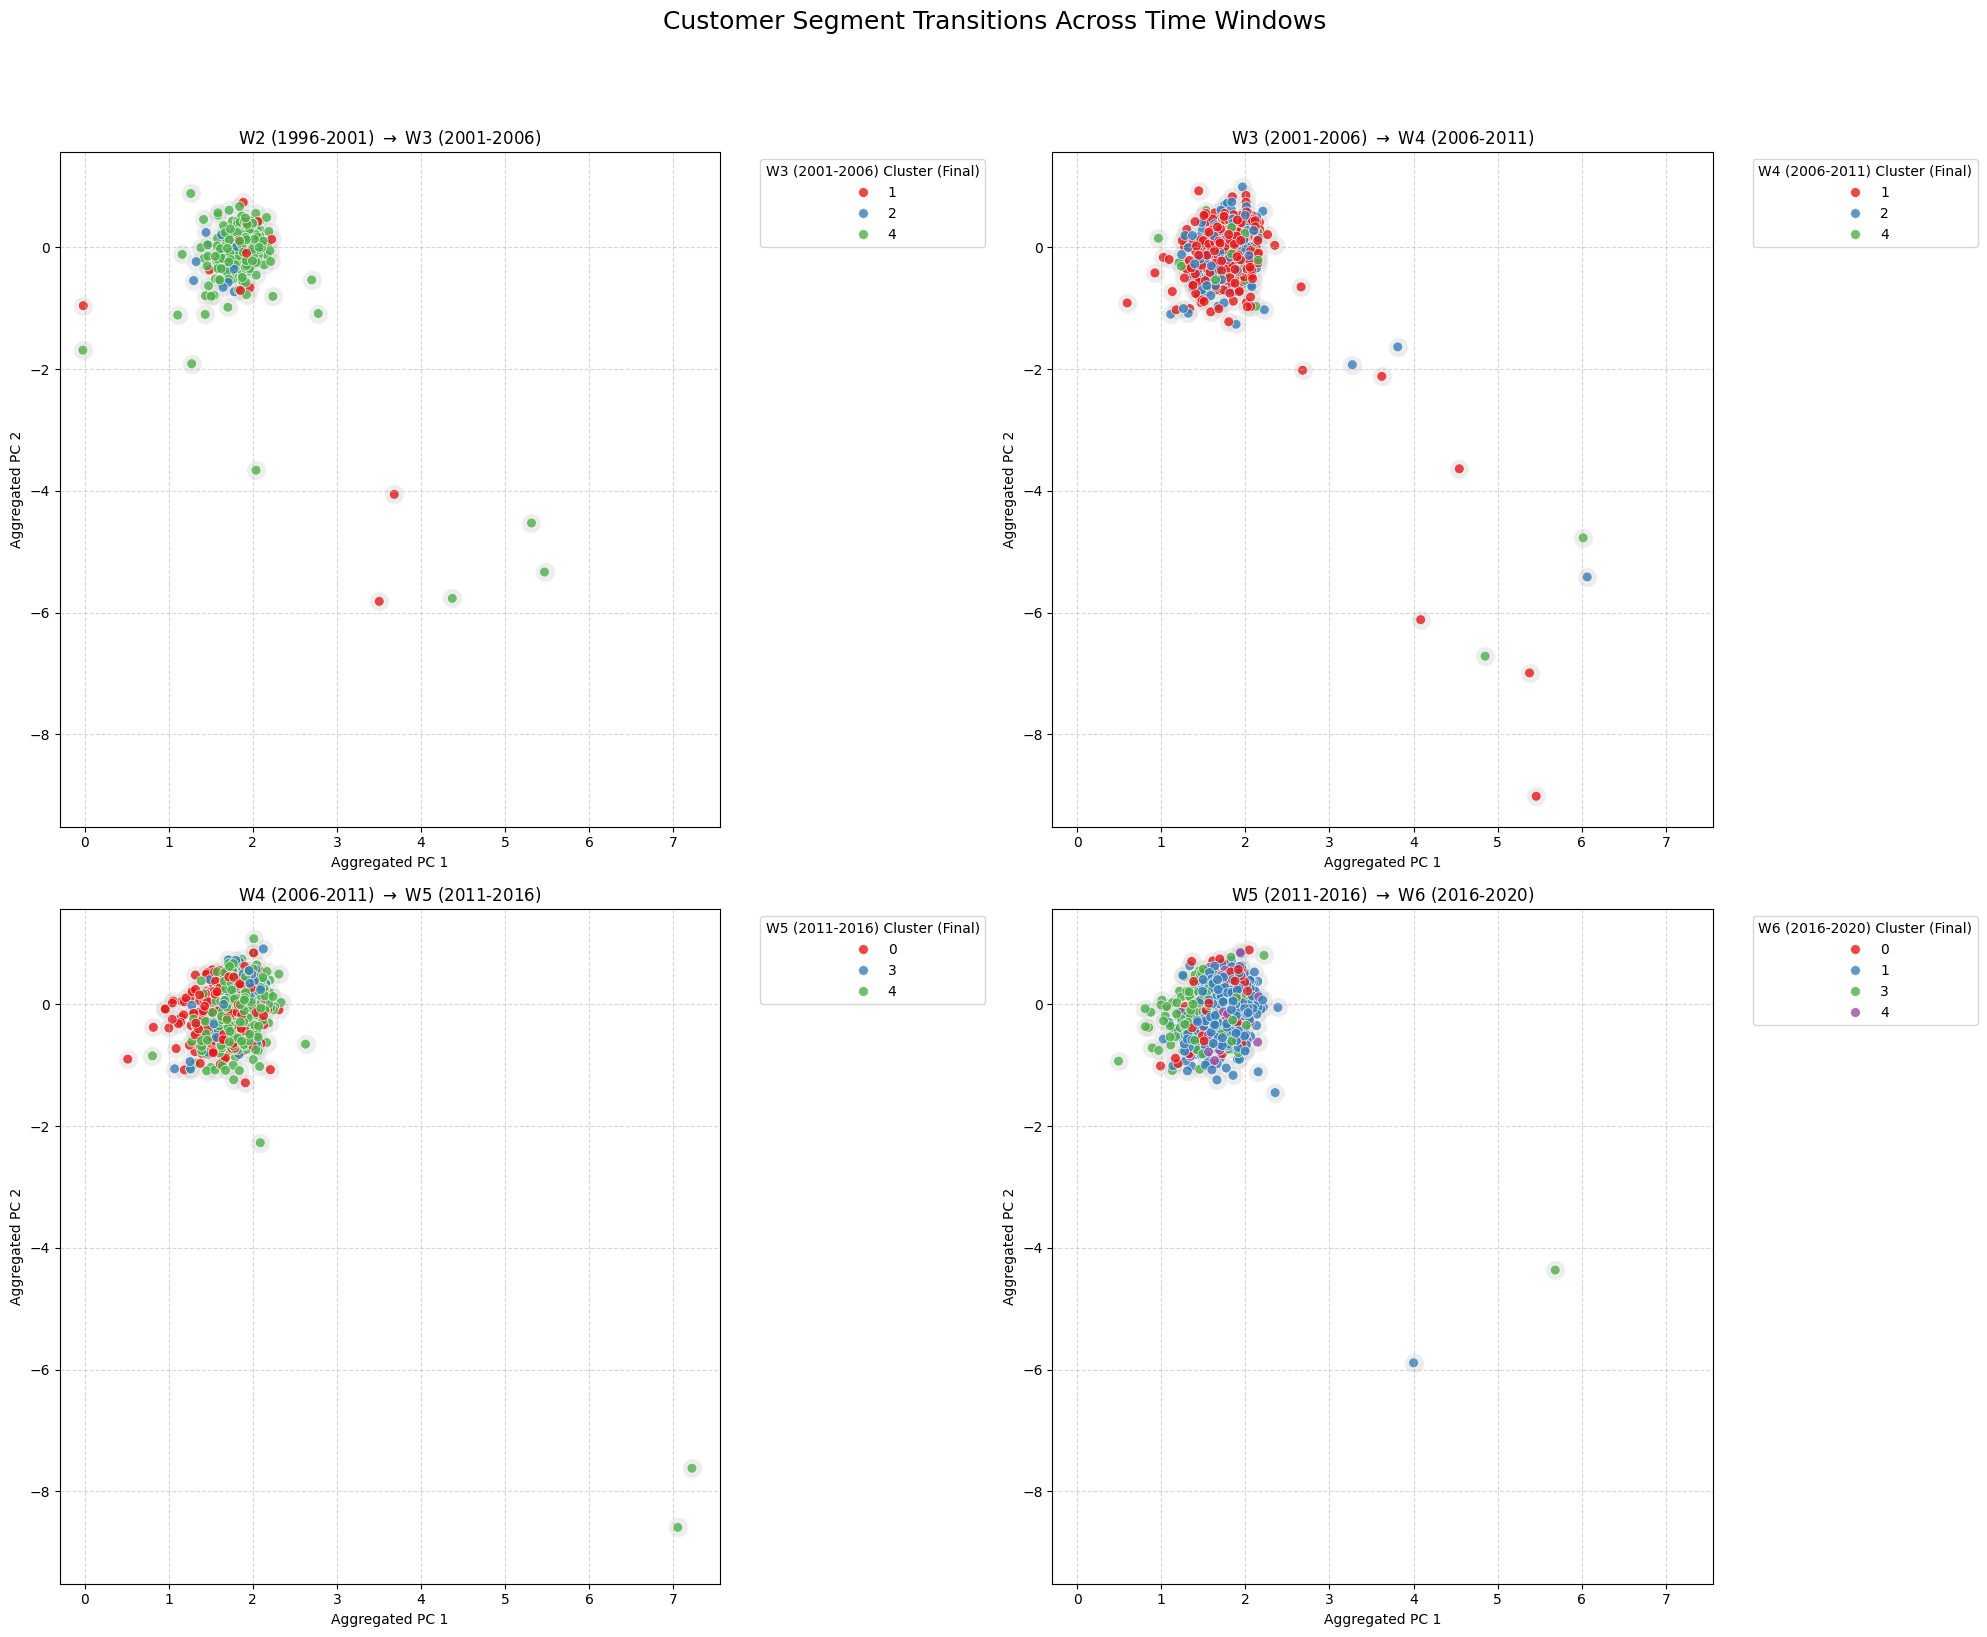

In [35]:
def plot_transition_scatter(W1_NAME, W2_NAME, all_features, all_cluster_labels, ax, return_df=False, max_points=2000):
    """Scatter of customer positions in W1's PC space: faint background = W1 cluster,
    colored foreground = aligned W2 cluster."""
    feat_w1 = all_features[W1_NAME].copy().reset_index().rename(columns={'index': 'user_id'})
    pca_mean_cols = feat_w1.filter(regex='(PC_.*mean)').columns.tolist()
    rfm_cols = ['Recency_Days', 'Total_Spend', 'Total_Transactions']
    df_w1_data = feat_w1[['user_id', 'Cluster'] + pca_mean_cols + rfm_cols].copy()

    df_w2_labels = all_cluster_labels[W2_NAME][['user_id', 'Aligned_Cluster']].copy()
    df_transition_plot = pd.merge(df_w1_data, df_w2_labels, on='user_id', how='inner')
    df_transition_plot = df_transition_plot.rename(columns={'Cluster': 'Cluster_W1'})
    df_transition_plot['Cluster_W1'] = df_transition_plot['Cluster_W1'].astype('category')
    df_transition_plot['Aligned_Cluster'] = df_transition_plot['Aligned_Cluster'].astype('category')

    df_plot = (df_transition_plot.sample(max_points, random_state=42)
               if len(df_transition_plot) > max_points else df_transition_plot)

    sns.scatterplot(x='PC_1_mean', y='PC_2_mean', data=df_plot, color='lightgrey',
                     s=200, alpha=0.4, legend=False, ax=ax)
    sns.scatterplot(x='PC_1_mean', y='PC_2_mean', data=df_plot, hue='Aligned_Cluster',
                     palette='Set1', s=50, alpha=0.8, ax=ax)

    ax.set_title(f'{W1_NAME} $\\rightarrow$ {W2_NAME}', fontsize=12)
    ax.set_xlabel('Aggregated PC 1')
    ax.set_ylabel('Aggregated PC 2')
    ax.legend(title=f'{W2_NAME} Cluster (Final)', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.5)

    if return_df:
        return df_transition_plot


window_pairs = [(processed_windows[i], processed_windows[i + 1]) for i in range(len(processed_windows) - 1)]
print(f"Generating {len(window_pairs)} transition plots: {window_pairs}\n")

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 16))
axes = axes.flatten()
used_axes = []

for i, (w1_name, w2_name) in enumerate(window_pairs):
    if i < len(axes):
        used_axes.append(axes[i])
        plot_transition_scatter(w1_name, w2_name, all_features, all_cluster_labels, ax=axes[i])

for j in range(len(window_pairs), len(axes)):
    fig.delaxes(axes[j])

if used_axes:
    x_min = min(ax.get_xlim()[0] for ax in used_axes)
    x_max = max(ax.get_xlim()[1] for ax in used_axes)
    y_min = min(ax.get_ylim()[0] for ax in used_axes)
    y_max = max(ax.get_ylim()[1] for ax in used_axes)
    for ax in used_axes:
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)

plt.suptitle('Customer Segment Transitions Across Time Windows', fontsize=18, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


In [36]:
w1_name, w2_name = "W5 (2011-2016)", "W6 (2016-2020)"
feat_w1 = all_features[w1_name].reset_index().rename(columns={'index': 'user_id'})
labels_w2 = all_cluster_labels[w2_name][['user_id', 'Aligned_Cluster']]

movers = feat_w1.merge(labels_w2, on='user_id', how='inner')

groups = {
    'Retained in Segment 3 (3→3)': movers[(movers['Cluster'] == 3) & (movers['Aligned_Cluster'] == 3)],
    'Migrated 3→1':                movers[(movers['Cluster'] == 3) & (movers['Aligned_Cluster'] == 1)],
    'Retained in Segment 1 (1→1)': movers[(movers['Cluster'] == 1) & (movers['Aligned_Cluster'] == 1)],
}

summary = pd.DataFrame({
    name: {
        'n': len(g),
        'Mean Recency': g['Recency_Days'].mean(),
        'Mean Spend': g['Total_Spend'].mean(),
        'Mean Transactions': g['Total_Transactions'].mean(),
    }
    for name, g in groups.items()
}).T
summary

,n,Mean Recency,Mean Spend,Mean Transactions
Retained in Segment 3 (3→3),183.0,0.032787,294267.723934,6984.612022
Migrated 3→1,137.0,10.145985,225694.774088,4778.394161
Retained in Segment 1 (1→1),798.0,9.944862,215800.805376,4699.008772


Movers from Segment 3 to Segment 1 show a marked drop in transaction count and total spend relative to stable Segment 3 members, alongside an increase in recency — and their resulting profile closely resembles stable Segment 1 customers. This pattern is consistent with a gradual decline in card activity: high-value customers who start reducing both volume and spend, while becoming slightly less recent, tend to migrate into a mid-value lifestyle segment rather than dropping straight to dormant. Migration paths like this one are a natural basis for early-warning signals in retention and win-back strategies.

## Conclusion

Two feature representations were tested for customer segmentation: aggregate customer-level statistics reduced with PCA (Method A) and transaction-level behavioral features reduced with Truncated SVD and combined with RFM metrics (Method B). The two produced almost no agreement (ARI = 0.023), showing they capture genuinely different structure rather than converging on the same segmentation from different angles. Method B's transaction-level features were used for the primary segmentation, since they retain sequencing, timing, and merchant-category signal that customer-level aggregates discard.

K-means at K=5 was chosen over the statistically-optimal K=3 (highest silhouette) or K=6 (lowest DBI) for interpretability and comparability with Method A — a deliberate trade-off, not a claim of optimal separation. Cross-algorithm comparison (GMM, Spectral Clustering) showed moderate agreement with K-means (ARI 0.557 and 0.576 respectively). The K-means solution itself showed moderate stability across ten random seeds (mean pairwise ARI ≈ 0.67, std ≈ 0.13), rather than near-complete agreement across runs.

The five resulting segments — Elite High-Volume Spenders, Recent Low-Value Trialists, Frequent Local In-Person Buyers, Balanced Card-Present Family Shoppers, and Dormant/Churn Risk customers — differ meaningfully in spend, transaction frequency, recency, merchant-category diversity, and geographic footprint. The five-year rolling-window analysis showed that high-activity segments were largely stable over time, while smaller, lower-engagement segments migrated between clusters more readily — consistent with those segments representing more transient or borderline customer behavior rather than a fixed lifestyle.

**Limitations:** cluster separation is modest (Method B silhouette ≈ 0.19–0.22 depending on K), so segment boundaries should be read as a behavioral continuum rather than hard categories. Segment names are a manual interpretive layer applied on top of the RFM and SVD-loading profiles, not something the clustering algorithm outputs directly, and should be re-validated if the underlying data or feature set changes.

Not all behavioral motifs surface as their own cluster. Seasonal travelers — customers whose spend spikes during a specific window, like the trip that motivated this project — get absorbed into whichever broader high-usage segment they otherwise resemble, since the feature set aggregates behavior across the full multi-year window and emphasizes overall intensity and category mix rather than explicit seasonality. Surfacing that kind of pattern would need dedicated temporal features or a time-series approach rather than a single aggregated feature vector, and is a natural next step.

The motivating example here was avoiding unnecessary declines during travel, but the same lifestyle-aware segmentation extends to personalized marketing, loyalty design, and — with appropriate validation — refinement of existing fraud and risk strategies. All three benefit from the same underlying shift: describing how customers actually use their cards, instead of relying on static demographic or rule-based labels.
